# Графовый анализ научных публикаций arXiv
## Контрфактические объяснения и алгоритмические рекомендации

Контрфактическое объяснение показывает, какие изменения объекта могут изменить решение модели. Algorithmic recourse рассматривает, насколько такие изменения доступны человеку.

Цель работы - собрать корпус публикаций, провести разведочный анализ, выделить ключевые слова, исследовать их граф и реализовать поиск близких публикаций.

| Пункт задания | Раздел |
|:--|:--|
| 1-2 | Выбор темы и сбор корпуса через arXiv API |
| 3 | Разведочный анализ и закон Ципфа |
| 4 | Нормализация и выделение ключевых слов |
| 5 | Граф ключевых слов |
| 6 | Кластеры и модульность |
| 7 | Центральности |
| 8-9 | Граф публикаций, поиск и тестирование |


## Подготовка среды

Файл `data/arxiv_counterfactual_corpus.csv` содержит ответ arXiv API. При обычном запуске используется этот файл. Чтобы заново обратиться к API, в разделе сбора данных нужно установить `REFRESH_DATA = True`.

Необходимые библиотеки: NumPy, pandas, Matplotlib, NetworkX, scikit-learn и snowballstemmer.


In [1]:
from pathlib import Path
import re
import time
import urllib.error
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from functools import lru_cache
from itertools import combinations
from textwrap import fill

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import snowballstemmer
from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import adjusted_rand_score

RANDOM_STATE = 42
MIN_DATE = '2020-01-01'
MAX_DATE = '2026-09-19'
TOP_N_KEYWORDS = 12
DATA_PATH = Path('data') / 'arxiv_counterfactual_corpus.csv'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
pd.set_option('display.max_colwidth', 100)


## 1. Выбор темы и сбор корпуса — пункты 1–2

Тема работы — контрфактические объяснения и алгоритмические рекомендации. Это узкое направление объяснимого искусственного интеллекта.

Данные получены через официальный [arXiv API](https://info.arxiv.org/help/api/user-manual.html). В названии или аннотации ищутся фразы `counterfactual explanation`, `counterfactual explanations` и `algorithmic recourse`. Дата первой публикации ограничена периодом с 01.01.2020 по 19.09.2026.

Для каждой публикации сохраняются идентификатор, название, авторы, аннотация, дата, категории и ссылка. Загруженные записи дополнительно проверяются локально.


In [2]:
ARXIV_API = 'https://export.arxiv.org/api/query'
NS = {'atom': 'http://www.w3.org/2005/Atom',
      'open': 'http://a9.com/-/spec/opensearch/1.1/'}
SEARCH_QUERY = (
    '(ti:"counterfactual explanation" OR abs:"counterfactual explanation" OR '
    'ti:"counterfactual explanations" OR abs:"counterfactual explanations" OR '
    'ti:"algorithmic recourse" OR abs:"algorithmic recourse") AND '
    'submittedDate:[202001010000 TO 202609192359]'
)

def request_page(start, page_size=1000, attempts=3):
    params = {'search_query': SEARCH_QUERY, 'start': start, 'max_results': page_size,
              'sortBy': 'submittedDate', 'sortOrder': 'descending'}
    url = ARXIV_API + '?' + urllib.parse.urlencode(params)
    request = urllib.request.Request(url, headers={'User-Agent': 'counterfactual-graph-lab/1.0'})
    for attempt in range(attempts):
        try:
            with urllib.request.urlopen(request, timeout=90) as response:
                return response.read()
        except urllib.error.HTTPError as error:
            if error.code not in {429, 500, 502, 503, 504} or attempt == attempts - 1:
                raise
        except (urllib.error.URLError, TimeoutError):
            if attempt == attempts - 1:
                raise
        time.sleep(10 * (attempt + 1))

def parse_feed(xml_bytes):
    root = ET.fromstring(xml_bytes)
    records = []
    for entry in root.findall('atom:entry', NS):
        url = entry.findtext('atom:id', default='', namespaces=NS)
        paper_id = re.sub(r'v\d+$', '', url.split('/abs/')[-1])
        records.append({
            'id': paper_id,
            'title': ' '.join(entry.findtext('atom:title', default='', namespaces=NS).split()),
            'authors': [a.findtext('atom:name', default='', namespaces=NS)
                        for a in entry.findall('atom:author', NS)],
            'abstract': ' '.join(entry.findtext('atom:summary', default='', namespaces=NS).split()),
            'published': entry.findtext('atom:published', default='', namespaces=NS)[:10],
            'categories': [c.attrib['term'] for c in entry.findall('atom:category', NS)],
            'url': f'https://arxiv.org/abs/{paper_id}'
        })
    total = int(root.findtext('open:totalResults', default=str(len(records)), namespaces=NS))
    return records, total

def fetch_arxiv():
    records = []
    start = 0
    while True:
        if start:
            time.sleep(3)
        page, total = parse_feed(request_page(start))
        records.extend(page)
        start += len(page)
        print(f'Загружено {start} из {total}')
        if start >= total or not page:
            break
    return pd.DataFrame(records)


In [3]:
REFRESH_DATA = False

if REFRESH_DATA:
    raw_corpus = fetch_arxiv()
    saved = raw_corpus.copy()
    saved['authors'] = saved['authors'].map(lambda values: '; '.join(values))
    saved['categories'] = saved['categories'].map(lambda values: ', '.join(values))
    DATA_PATH.parent.mkdir(exist_ok=True)
    saved.to_csv(DATA_PATH, index=False, encoding='utf-8-sig')
else:
    if not DATA_PATH.exists():
        raise FileNotFoundError(f'Не найден файл {DATA_PATH}')
    raw_corpus = pd.read_csv(DATA_PATH, dtype={'id': str})
    raw_corpus['authors'] = raw_corpus['authors'].map(lambda value: value.split('; '))
    raw_corpus['categories'] = raw_corpus['categories'].map(lambda value: value.split(', '))

corpus = raw_corpus.drop_duplicates('id').copy()
corpus['published'] = pd.to_datetime(corpus['published'], errors='coerce')
topic_pattern = r'\bcounterfactual\s+explanations?\b|\balgorithmic\s+recourse\b'
topic_text = (corpus['title'] + ' ' + corpus['abstract']).str.lower().str.replace('-', ' ', regex=False)
valid = (
    corpus['published'].between(MIN_DATE, MAX_DATE)
    & corpus['title'].str.strip().ne('')
    & corpus['abstract'].str.strip().ne('')
    & corpus['authors'].map(lambda values: bool(values) and all(value.strip() for value in values))
    & topic_text.str.contains(topic_pattern, regex=True)
)
rejected = corpus.loc[~valid, ['id', 'title']]
corpus = corpus.loc[valid].sort_values(['published', 'id'], ascending=False).reset_index(drop=True)
corpus['year'] = corpus['published'].dt.year
corpus['text'] = corpus['title'] + '. ' + corpus['abstract']

assert len(corpus) >= 300
assert corpus['id'].is_unique
assert corpus['published'].between(MIN_DATE, MAX_DATE).all()
assert corpus[['id', 'title', 'abstract', 'published']].notna().all().all()

print(f'Получено записей: {len(raw_corpus)}. После проверки: {len(corpus)}. Исключено: {len(rejected)}.')
print('Диапазон дат:', corpus['published'].min().date(), '—', corpus['published'].max().date())
display(corpus[['id', 'published', 'title', 'authors']].head(5))


Получено записей: 766. После проверки: 761. Исключено: 5.
Диапазон дат: 2020-01-21 — 2026-09-17


,id,published,title,authors
0,2609.20067,2026-09-17,FCA-Guided Counterfactual Explanations for Multi-Modal Breast Cancer Diagnosis: A Framework Achi...,"[Abdullahi Isa, Souley Boukari, Muhammad Aliyu]"
1,2609.19383,2026-09-16,FCx: An algorithm for finding Feasible Counterfactual Explanations,"[Kleopatra Markou, Vana Kalogeraki, Dimitrios Gunopulos]"
2,2609.18049,2026-09-16,Regional Explanations via Causal Sufficiency and Necessity,"[Xuexin Chen, Peng Liang, Zijian Li, Zhiyong Lin, Ruichu Cai]"
3,2609.13940,2026-09-12,"Optimal Transport for Efficient, Unsupervised Anomaly Detection on Industrial Data","[Abigail Langbridge, Fearghal O'Donncha, James T Rayfield, Bradley Eck]"
4,2609.12179,2026-09-10,Explanations-Driven Active Feature Acquisition for Algorithmic Recourse,"[Vinura Galwaduge, Jagath Samarabandu]"


В ответе API было 766 записей. После проверки осталось 761 уникальная публикация с 21.01.2020 по 17.09.2026. Пять записей исключены, поскольку локальная проверка не нашла заданные тематические фразы.

Корпус охватывает выдачу выбранного запроса, но не всю литературу по объяснимому ИИ: работы с другими формулировками могли не попасть в выборку.


## 3. Разведочный анализ — пункт 3

Проверяются пропуски, повторы, длины текстов, число авторов, распределения по годам
и категориям. Автор учитывается по строке имени из arXiv; однофамильцы и варианты
написания имени автоматически не разрешаются. Категории могут пересекаться.
Для подсчёта слов используются английские словоформы без удаления стоп-слов.

In [4]:
def words(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

corpus['title_words'] = corpus['title'].map(lambda text: len(words(text)))
corpus['abstract_words'] = corpus['abstract'].map(lambda text: len(words(text)))
corpus['author_count'] = corpus['authors'].map(len)
author_counts = Counter(author for authors in corpus['authors'] for author in authors)
category_counts = Counter(category for categories in corpus['categories'] for category in categories)
word_counts = Counter(word for text in corpus['text'] for word in words(text))

quality = pd.Series({
    'Публикаций': len(corpus),
    'Повторов ID': int(corpus['id'].duplicated().sum()),
    'Повторов названий': int(corpus['title'].str.casefold().duplicated().sum()),
    'Пропусков в обязательных полях': int(corpus[['title', 'abstract', 'published']].isna().sum().sum()),
    'Различных строк имён авторов': len(author_counts),
    'Словоупотреблений': sum(word_counts.values()),
    'Различных словоформ': len(word_counts)
}, name='Значение')
display(quality.to_frame())
display(corpus[['title_words', 'abstract_words', 'author_count']].describe().round(1))

,Значение
Публикаций,761
Повторов ID,0
Повторов названий,0
Пропусков в обязательных полях,0
Различных строк имён авторов,2138
Словоупотреблений,146067
Различных словоформ,7724


,title_words,abstract_words,author_count
count,761.0,761.0,761.0
mean,9.5,182.5,4.0
std,3.3,45.1,2.0
min,3.0,60.0,1.0
25%,7.0,150.0,3.0
50%,9.0,179.0,4.0
75%,11.0,217.0,5.0
max,27.0,302.0,27.0


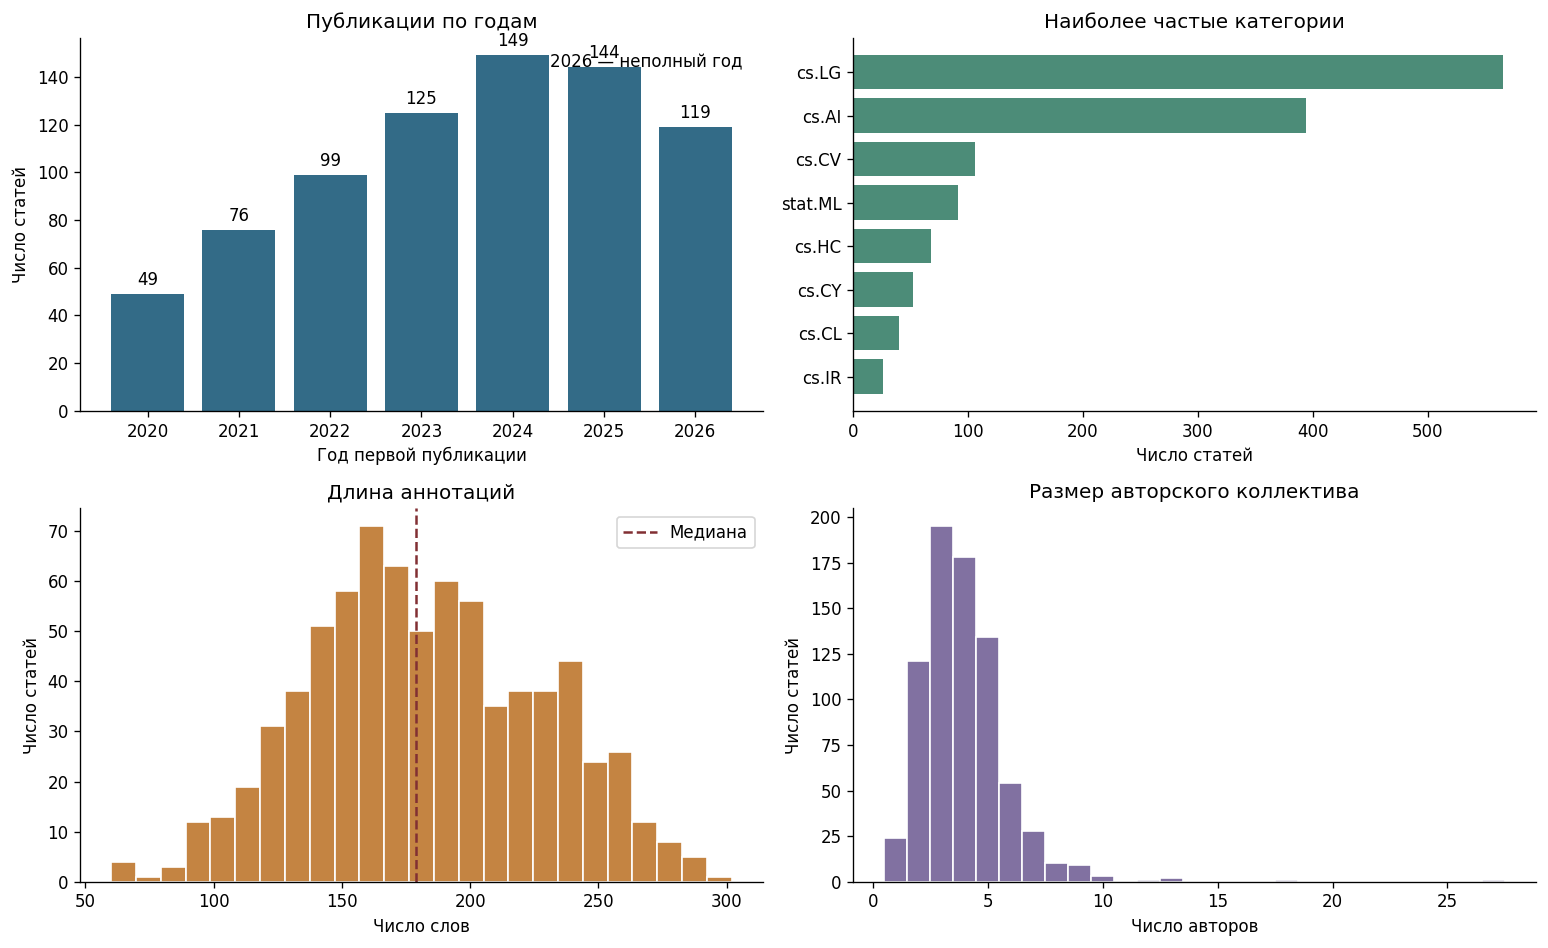

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
years = corpus['year'].value_counts().sort_index()
bars = axes[0, 0].bar(years.index.astype(str), years.values, color='#336b87')
axes[0, 0].bar_label(bars, padding=3)
axes[0, 0].set(title='Публикации по годам', xlabel='Год первой публикации', ylabel='Число статей')
axes[0, 0].text(0.97, 0.92, '2026 — неполный год', ha='right', transform=axes[0, 0].transAxes)

top_categories = pd.Series(dict(category_counts.most_common(8))).sort_values()
axes[0, 1].barh(top_categories.index, top_categories.values, color='#4c8c78')
axes[0, 1].set(title='Наиболее частые категории', xlabel='Число статей')

axes[1, 0].hist(corpus['abstract_words'], bins=25, color='#c48442', edgecolor='white')
axes[1, 0].axvline(corpus['abstract_words'].median(), color='#812f33', linestyle='--', label='Медиана')
axes[1, 0].set(title='Длина аннотаций', xlabel='Число слов', ylabel='Число статей')
axes[1, 0].legend()

axes[1, 1].hist(corpus['author_count'], bins=np.arange(0.5, corpus['author_count'].max() + 1.5),
                color='#8171a1', edgecolor='white')
axes[1, 1].set(title='Размер авторского коллектива', xlabel='Число авторов', ylabel='Число статей')
plt.tight_layout()
plt.show()

В 2020 году в корпусе 49 публикаций, в 2024 — 149, в 2025 — 144. Для выбранного
запроса это указывает на увеличение числа работ по сравнению с началом периода.
В 2026 году найдено 119 статей, но данные заканчиваются сентябрём: сравнивать это
значение с полным 2025 годом как свидетельство спада нельзя. Вывод относится
к публикациям arXiv с заданными фразами, а не ко всей научной литературе.

Распределения длин текстов и числа авторов нужны для проверки неоднородности корпуса:
длинная аннотация даёт больше кандидатов в ключевые слова. В дальнейшем применяется
нормировка TF-IDF, а число тегов ограничивается. Сумма частот категорий превышает
число статей, поскольку одна работа может относиться к нескольким категориям.

### Проверка закона Ципфа

Для слов, упорядоченных по убыванию частоты, закон Ципфа задаёт зависимость
$f(r) \approx C r^{-s}$, где $r$ — ранг, а $s$ близок к единице.
На логарифмических осях ожидается приблизительно прямая с наклоном $-s$.
Здесь учитываются все словоформы названий и аннотаций, включая стоп-слова,
**до стемминга**. Для сопоставления оцениваются наклоны на всём словаре и в
средней части распределения; диапазон рангов задаётся заранее.

,Диапазон,Наклон,s,R²,Слов
0,Весь словарь,-1.371,1.371,0.964,7724
1,Ранги 10–1000,-0.936,0.936,0.995,991


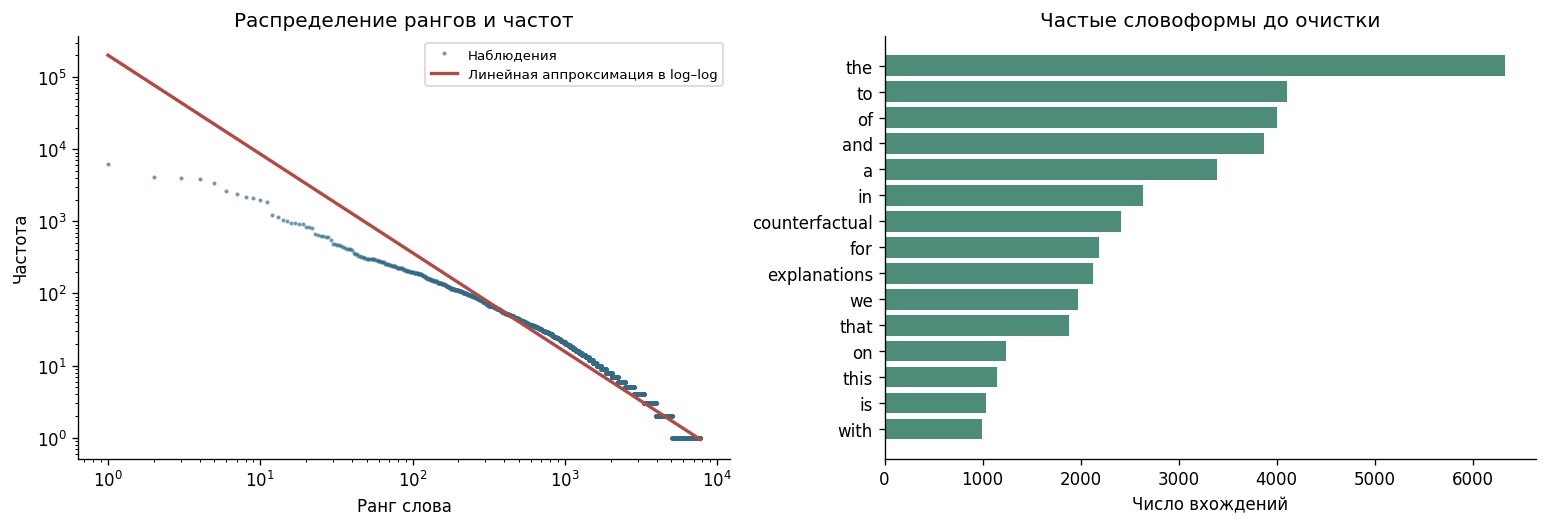

In [6]:
frequencies = np.array(sorted(word_counts.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)
zipf_rows = []
zipf_models = {}
for name, mask in {
    'Весь словарь': np.ones(len(ranks), dtype=bool),
    'Ранги 10–1000': (ranks >= 10) & (ranks <= 1000)
}.items():
    x = np.log10(ranks[mask]).reshape(-1, 1)
    y = np.log10(frequencies[mask])
    model = LinearRegression().fit(x, y)
    zipf_models[name] = model
    zipf_rows.append({'Диапазон': name, 'Наклон': model.coef_[0],
                      's': -model.coef_[0], 'R²': model.score(x, y), 'Слов': mask.sum()})
zipf_table = pd.DataFrame(zipf_rows)
display(zipf_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(ranks, frequencies, '.', ms=3, alpha=0.55, color='#336b87', label='Наблюдения')
fit = zipf_models['Весь словарь']
axes[0].loglog(ranks, 10 ** fit.predict(np.log10(ranks).reshape(-1, 1)),
               color='#b14a42', lw=2, label='Линейная аппроксимация в log–log')
axes[0].set(xlabel='Ранг слова', ylabel='Частота', title='Распределение рангов и частот')
axes[0].legend(fontsize=8)
top_words = pd.Series(dict(word_counts.most_common(15))).sort_values()
axes[1].barh(top_words.index, top_words.values, color='#4c8c78')
axes[1].set(title='Частые словоформы до очистки', xlabel='Число вхождений')
plt.tight_layout()
plt.show()

Частые служебные слова образуют начало распределения, а редкая терминология —
длинный хвост. Ступени в хвосте возникают из-за целочисленных частот, в том числе
слов с одним вхождением. Наклон и R² описывают приближение на указанных диапазонах.
Даже высокий R² в логарифмических координатах не доказывает степенной закон:
для строгой проверки потребовались бы отдельная статистическая модель хвоста
и сравнение с альтернативными распределениями. Здесь проверяется соответствие
характерной форме закона Ципфа.

## 4. Ключевые слова — пункт 4

Единица анализа — **название + аннотация**. Нормализация включает нижний регистр
и английский Snowball-стемминг. Варианты `explanation` и `explanations`, например,
получают одну основу. На рисунках и в таблицах вместо основы показывается наиболее
частая исходная форма; при подсчётах используются именно нормализованные теги.

Кандидаты — последовательные униграммы, биграммы и триграммы. Они не пересекают
границы предложений и не склеиваются через удалённые стоп-слова. Убираются URL,
формулы между знаками `$` и команды LaTeX. Дефис считается разделителем слов.
Это простая очистка аннотаций, а не полный синтаксический разбор LaTeX.

Используется TF-IDF с `sublinear_tf=True`, `min_df=3`, `max_df=0.85` и L2-нормировкой.
Слишком редкие и почти общие для корпуса выражения исключаются. Из 36 кандидатов
с наибольшим TF-IDF убираются вложенные фразы, после чего остаётся до 12 тегов.
Например, `neural network` и `graph neural network` не учитываются одновременно
у одной статьи. Это снижает повторный учёт одной и той же фразы в весах рёбер.

In [7]:
stopwords = set(ENGLISH_STOP_WORDS) | {
    'paper', 'study', 'studies', 'propose', 'proposed', 'present', 'presented',
    'method', 'methods', 'result', 'results', 'using', 'used', 'based',
    'show', 'shows', 'approach', 'et', 'al'
}
stemmer = snowballstemmer.stemmer('english')

@lru_cache(maxsize=None)
def stem_word(word):
    return stemmer.stemWord(word)

def candidate_terms(text):
    text = re.sub(r'https?://\S+', '.', text.lower())
    text = re.sub(r'\$[^$]*\$', '.', text)
    text = re.sub(r'\\[a-z]+', '.', text)
    for fragment in re.split(r'[^a-z\s]+', text.replace('-', ' ')):
        tokens = fragment.split()
        for size in (1, 2, 3):
            for start in range(len(tokens) - size + 1):
                phrase = tokens[start:start + size]
                if all((len(w) >= 3 or w in {'ai', 'ml', 'rl'}) and w not in stopwords for w in phrase):
                    yield ' '.join(stem_word(w) for w in phrase), ' '.join(phrase)

def extract_terms(text):
    return [term for term, surface in candidate_terms(text)]

def is_nested(short, long):
    return short != long and f' {short} ' in f' {long} '

def select_keywords(row, terms, top_n=TOP_N_KEYWORDS):
    ranked = sorted(zip(row.indices, row.data), key=lambda pair: (-pair[1], terms[pair[0]]))
    candidates = [terms[i] for i, score in ranked[:3 * top_n]]
    selected = [term for term in candidates
                if not any(is_nested(term, other) for other in candidates)]
    return selected[:top_n]

assert stem_word('explanation') == stem_word('explanations')
assert 'neural network' not in extract_terms('Neural. Network')
assert 'neural network' not in extract_terms('Neural and network')
assert not is_nested('age', 'agent')

Размер матрицы TF-IDF: (761, 3859)
Различных выбранных тегов: 3270
Тегов на статью: от 12 до 12


,Основа,Ключевое слово,Статей
0,ces,ces,17
1,bias,bias,16
2,cfes,cfes,16
3,llms,llms,15
4,score,scores,15
5,xai,xai,15
6,sparsiti,sparsity,13
7,region,regions,13
8,algorithm recours,algorithmic recourse,13
9,path,path,13


,id,title,keywords
0,2609.20067,FCA-Guided Counterfactual Explanations for Multi-Modal Breast Cancer Diagnosis: A Framework Achieving Perfect Validity with Emergent Sparsity,"multi modal, breast, perfect validity, cancer, sparsity, nice, diagnosis, best, clinical, auc, genuine, largest"
1,2609.19383,FCx: An algorithm for finding Feasible Counterfactual Explanations,"feasibility constraints, feasible counterfactual explanations, low cost, absolute, dense, lof, explanations identify, job, reside, density estimator, multiple metrics, race"
100,2601.22653,Human-Centered Explainability in AI-Enhanced UI Security Interfaces: Designing Trustworthy Copilots for Cybersecurity Analysts,"analysts, cybersecurity, security, human centered, style, controlled user, explanation design, explanation strategy, guidelines, triage, user interface, high stakes"
300,2409.09461,TX-Gen: Multi-Objective Optimization for Sparse Counterfactual Explanations for Time-Series Classification,"time series classification, multi objective optimization, change model, non dominated, original time series, promising solution, sort, benchmark datasets demonstrate, evolutionary, time series models, understanding model, alternative inputs"
600,2205.15406,From Explanation to Recommendation: Ethical Standards for Algorithmic Recourse,"purpose, ethical, algorithmic recourse, traction, capabilities, standard, agree, explanation problem, contestability, user trust, allowing users, rationale"


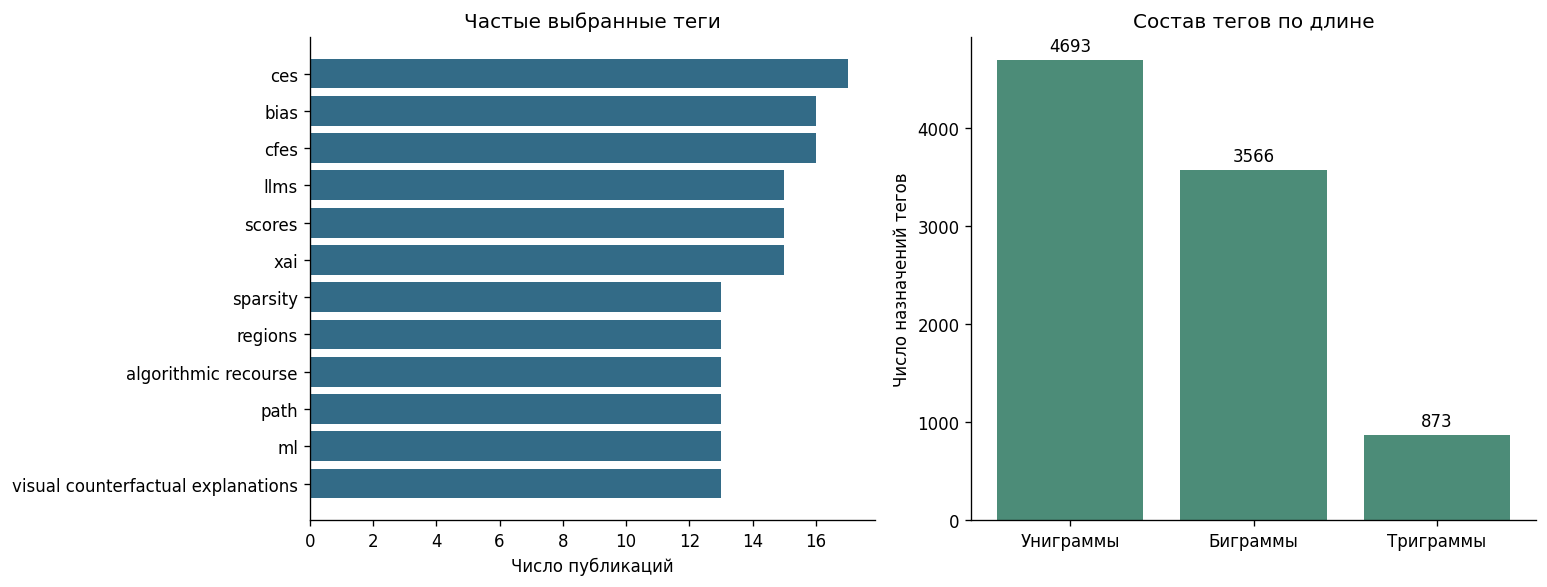

In [8]:
vectorizer = TfidfVectorizer(analyzer=extract_terms, min_df=3, max_df=0.85, sublinear_tf=True)
tfidf = vectorizer.fit_transform(corpus['text'])
terms = np.array(vectorizer.get_feature_names_out())
corpus['keywords'] = [select_keywords(row, terms) for row in tfidf]

forms = defaultdict(Counter)
for text in corpus['text']:
    for term, surface in candidate_terms(text):
        forms[term][surface] += 1
labels = {term: sorted(counts, key=lambda x: (-counts[x], x))[0] for term, counts in forms.items()}
keyword_counts = Counter(term for tags in corpus['keywords'] for term in set(tags))

assert corpus['keywords'].map(bool).all()
assert all(len(tags) == len(set(tags)) for tags in corpus['keywords'])
assert all(not any(is_nested(a, b) or is_nested(b, a) for a, b in combinations(tags, 2))
           for tags in corpus['keywords'])

print('Размер матрицы TF-IDF:', tfidf.shape)
print('Различных выбранных тегов:', len(keyword_counts))
print('Тегов на статью: от', corpus['keywords'].map(len).min(), 'до', corpus['keywords'].map(len).max())
keyword_table = pd.DataFrame([
    {'Основа': term, 'Ключевое слово': labels[term], 'Статей': count}
    for term, count in keyword_counts.most_common(20)
])
display(keyword_table)
examples = corpus.loc[[0, 1, 100, 300, 600], ['id', 'title', 'keywords']].copy()
examples['keywords'] = examples['keywords'].map(lambda tags: ', '.join(labels[t] for t in tags))
with pd.option_context('display.max_colwidth', None):
    display(examples)

sizes = Counter(len(term.split()) for tags in corpus['keywords'] for term in tags)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top = keyword_table.head(12).iloc[::-1]
axes[0].barh(top['Ключевое слово'], top['Статей'], color='#336b87')
axes[0].set(title='Частые выбранные теги', xlabel='Число публикаций')
bars = axes[1].bar(['Униграммы', 'Биграммы', 'Триграммы'], [sizes[n] for n in (1, 2, 3)], color='#4c8c78')
axes[1].bar_label(bars, padding=3)
axes[1].set(title='Состав тегов по длине', ylabel='Число назначений тегов')
plt.tight_layout()
plt.show()

TF-IDF выделяет выражения, характерные для отдельных работ относительно этого
корпуса. Частота в таблице — число публикаций, где выражение выбрано тегом;
она отличается от числа его вхождений в исходные тексты.

Нормализация объединяет грамматические варианты, но не все синонимы и сокращения:
`gnn` и `graph neural network`, например, могут остаться разными вершинами.
Статистическая биграмма или триграмма не обязательно является устойчивым термином.
Поэтому ниже кластеры рассматриваются вместе с названиями и аннотациями
представляющих их статей, а качество поиска дополнительно проверяется вручную.

## 5. Граф ключевых слов — пункт 5

Вершина — нормализованное ключевое слово. Два слова связаны, если они выбраны
тегами хотя бы одной общей публикации. Вес равен числу таких публикаций:

$$w_{ij}=\sum_{d=1}^{N} \mathbf{1}(i\in K_d)\mathbf{1}(j\in K_d), \qquad i\ne j.$$

Повторы слова внутри одной статьи не увеличивают вес. Петли не создаются.
Основной анализ проводится на полном графе: пороги веса рассматриваются
отдельно, чтобы не получить искусственно высокую модульность после распада
графа на множество небольших компонент.

In [9]:
keyword_graph = nx.Graph()
keyword_graph.add_nodes_from(sorted(keyword_counts))
for tags in corpus['keywords']:
    for left, right in combinations(sorted(set(tags)), 2):
        if keyword_graph.has_edge(left, right):
            keyword_graph[left][right]['weight'] += 1
        else:
            keyword_graph.add_edge(left, right, weight=1)
for node in keyword_graph:
    keyword_graph.nodes[node]['label'] = labels[node]
    keyword_graph.nodes[node]['document_frequency'] = keyword_counts[node]
for left, right, edge in keyword_graph.edges(data=True):
    edge['distance'] = 1 / edge['weight']

keyword_components = list(nx.connected_components(keyword_graph))
display(pd.Series({
    'Вершины': keyword_graph.number_of_nodes(), 'Рёбра': keyword_graph.number_of_edges(),
    'Компоненты связности': len(keyword_components),
    'Крупнейшая компонента': max(map(len, keyword_components)),
    'Плотность': nx.density(keyword_graph),
    'Средняя степень': np.mean([degree for node, degree in keyword_graph.degree()])
}, name='Значение').to_frame())
assert nx.number_of_selfloops(keyword_graph) == 0

,Значение
Вершины,3270.000000
Рёбра,49313.000000
Компоненты связности,1.000000
Крупнейшая компонента,3270.000000
Плотность,0.009226
Средняя степень,30.160856


## 6. Кластеры ключевых слов — пункт 6

Для взвешенного графа применяется Louvain с `resolution=1` и фиксированным
`seed=42`. Алгоритм ищет разбиение с высокой модульностью — избытком связей
внутри сообществ относительно модели с теми же взвешенными степенями.
Найденное разбиение не обязано быть единственным или глобально оптимальным.
Модульность не является долей правильно классифицированных слов.

Кластеры нумеруются по убыванию размера. Для интерпретации выводятся частые теги
каждого кластера и две статьи с максимальным числом его тегов.

In [10]:
communities = nx.community.louvain_communities(keyword_graph, weight='weight', seed=RANDOM_STATE)
communities = sorted(communities, key=lambda group: (-len(group), sorted(group)[0]))
partition = {word: i + 1 for i, group in enumerate(communities) for word in sorted(group)}
modularity = nx.community.modularity(keyword_graph, communities, weight='weight')
nx.set_node_attributes(keyword_graph, partition, 'community')

cluster_rows = []
cluster_examples = []
for number, group in enumerate(communities, start=1):
    top = sorted(group, key=lambda word: (-keyword_counts[word], word))[:10]
    cluster_rows.append({'Кластер': number, 'Слов': len(group),
                         'Частые теги': ', '.join(labels[word] for word in top)})
    overlaps = corpus['keywords'].map(lambda tags: len(set(tags) & group))
    for index in overlaps.nlargest(2).index:
        cluster_examples.append({'Кластер': number, 'Общих тегов': int(overlaps[index]),
                                 'id': corpus.at[index, 'id'], 'Статья': corpus.at[index, 'title']})
cluster_table = pd.DataFrame(cluster_rows)
cluster_example_table = pd.DataFrame(cluster_examples)
print(f'Кластеров: {len(communities)}. Модульность полного графа: {modularity:.4f}.')
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(cluster_table)
    display(cluster_example_table)

Кластеров: 27. Модульность полного графа: 0.3362.


,Кластер,Слов,Частые теги
0,1,288,"bias, attribution, visual counterfactual explanations, general, diffusion, generative models, maps, semantic, regularization, robust"
1,2,211,"algorithmic recourse, adaptive, ai systems, ml models, sequence, temporal, variables, generate ces, plausible, adversarial training"
2,3,170,"cfes, probabilistic, uncertainty, complete, local, acceptance, approximate, guarantees, samples, certain"
3,4,165,"model changes, cause, neural networks, scalable, building, criteria, order, uncertainty estimates, accelerate, algorithm generates"
4,5,156,"ces, ml, feasible, ensemble, explainable ai, extend, interface, operating, proposes, unified"
5,6,154,"predictive models, test, interventions, control, dynamics, signals, risk, clinical, inference, recommendations"
6,7,148,"llms, cfs, large language models, interactive, prompt, attacks, causal relationships, investigate, evaluating counterfactual explanations, agree"
7,8,143,"item, rate, block, comprehensive, develop, feature space, management, solution, counterfactual generation algorithms, flow"
8,9,138,"strategies, aware, model agnostic, participants, analyze, class, correct, counterfactual instances, objective, surrogate model"
9,10,138,"concept, gnns, graph neural networks, counterfactual explainability, constraints, removal, correlations, architectures, bayesian, counterfactual reasoning"


,Кластер,Общих тегов,id,Статья
0,1,12,2602.04028,Axiomatic Foundations of Counterfactual Explanations
1,1,12,2601.18678,Counterfactual Explanations on Robust Perceptual Geodesics
2,2,12,2601.20449,Fair Recourse for All: Ensuring Individual and Group Fairness in Counterfactual Explanations
3,2,12,2601.16205,Counterfactual Training: Teaching Models Plausible and Actionable Explanations
4,3,12,2605.17160,When Bits Break Recourse: Counterfactual-Faithful Quantization
5,3,12,2407.19436,X-Fake: Juggling Utility Evaluation and Explanation of Simulated SAR Images
6,4,12,2502.07214,Pareto Optimal Algorithmic Recourse in Multi-cost Function
7,4,12,2208.14878,Formalising the Robustness of Counterfactual Explanations for Neural Networks
8,5,12,2512.04833,Counterfactual Explanations for Power System Optimisation
9,5,12,2502.13751,RobustX: Robust Counterfactual Explanations Made Easy


In [11]:
stability_rows = []
node_order = sorted(keyword_graph)
reference = [partition[node] for node in node_order]
for seed in (0, 7, 42, 99, 2026):
    groups = nx.community.louvain_communities(keyword_graph, weight='weight', seed=seed)
    membership = {word: i for i, group in enumerate(groups) for word in group}
    stability_rows.append({
        'seed': seed, 'Кластеров': len(groups),
        'Модульность': nx.community.modularity(keyword_graph, groups, weight='weight'),
        'ARI относительно seed=42': adjusted_rand_score(reference, [membership[n] for n in node_order])
    })
stability_table = pd.DataFrame(stability_rows)
display(stability_table.round(3))

threshold_rows = []
for threshold in (1, 2, 3):
    graph = keyword_graph.copy()
    graph.remove_edges_from([(a, b) for a, b, edge in graph.edges(data=True) if edge['weight'] < threshold])
    if threshold > 1:
        graph.remove_nodes_from(list(nx.isolates(graph)))
    groups = nx.community.louvain_communities(graph, weight='weight', seed=RANDOM_STATE)
    components = list(nx.connected_components(graph))
    threshold_rows.append({
        'Минимальный вес': threshold, 'Вершин': len(graph), 'Рёбер': graph.number_of_edges(),
        'Компонент': len(components), 'Крупнейшая компонента': max(map(len, components), default=0),
        'Модульность': nx.community.modularity(graph, groups, weight='weight') if graph.number_of_edges() else np.nan
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))

,seed,Кластеров,Модульность,ARI относительно seed=42
0,0,23,0.336,0.118
1,7,25,0.335,0.134
2,42,27,0.336,1.000
3,99,22,0.339,0.122
4,2026,25,0.335,0.136


,Минимальный вес,Вершин,Рёбер,Компонент,Крупнейшая компонента,Модульность
0,1,3270,49313,1,3270,0.336
1,2,749,829,172,103,0.960
2,3,74,71,25,9,0.871


### Интерпретация кластеров

Louvain выделил 27 сообществ при модульности 0,336. Это умеренное, а не идеальное
разделение: корпус посвящён одной области, поэтому общие понятия связывают разные
направления. Таблица показывает все кластеры; наиболее содержательные примеры:

- **Кластер 1 — визуальные и генеративные объяснения.** В него вошли `bias`,
  `attribution`, `visual counterfactual explanations`, `diffusion`,
  `generative models`, `maps`, `regularization`, `robust`. Эти выражения
  совместно встречаются в работах о построении визуальных контрфактов и проверке
  их устойчивости, например *Counterfactual Explanations on Robust Perceptual
  Geodesics*.
- **Кластер 2 — алгоритмические рекомендации и выполнимость изменений.** Теги
  `algorithmic recourse`, `adaptive`, `temporal`, `variables`, `plausible` и
  `adversarial training` описывают достижимость желаемого решения во времени.
  Это подтверждают статьи *Fair Recourse for All* и *Counterfactual Training*.
- **Кластер 6 — причинные вмешательства в клинических и динамических данных.**
  Здесь связаны `predictive models`, `interventions`, `control`, `dynamics`,
  `signals`, `risk`, `clinical`, `inference`. Типичные работы рассматривают
  последовательные медицинские данные и рекомендации при сердечной недостаточности.
- **Кластер 7 — контрфакты для больших языковых моделей.** Соседство `llms`,
  `large language models`, `interactive`, `prompt`, `attacks` и
  `causal relationships` возникает в исследованиях объяснения ответов LLM,
  неполных входных данных и причинного обратного поиска.
- **Кластер 10 — объяснения графовых нейронных сетей.** Теги `gnns`,
  `graph neural networks`, `constraints`, `removal`, `architectures` и
  `counterfactual reasoning` относятся к изменению вершин и рёбер графа для
  получения альтернативного предсказания.
- **Кластер 11 — справедливость и оспоримость решений.** `fairness`, `ethical`,
  `contestability`, `black box models`, `evidence` и `perspective` объединяются
  вокруг вопроса, достаточно ли объяснения и можно ли оспорить решение модели.
- **Кластер 13 — многомерные временные ряды.** `multivariate time series`,
  `sparsity`, `proximity`, `real time`, `time series data` отражают ограничения
  контрфактов для сигналов и прогнозов во времени.
- **Кластер 26 — приватный поиск контрфактов.** `privacy`, `database`,
  `information retrieval`, `model extraction attacks` и `private information`
  связаны с выдачей похожего контрфакта без раскрытия чувствительных данных.

При пяти запусках Louvain модульность почти не меняется: 0,335–0,339. Однако ARI
относительно `seed=42` составляет только 0,118–0,136. Следовательно, общая сила
разделения воспроизводится, но принадлежность многих отдельных слов нестабильна.
Кластеры корректно трактовать как разведочные тематические группы, а не как
единственную истинную классификацию терминов.

Порог веса 2 увеличивает модульность до 0,960, но оставляет 749 вершин в 172
компонентах, крупнейшая из которых содержит только 103 слова. Поэтому это число
не означает улучшение тематической модели: высокая модульность в основном связана
с распадом графа. Для содержательного анализа используется полный связный граф.

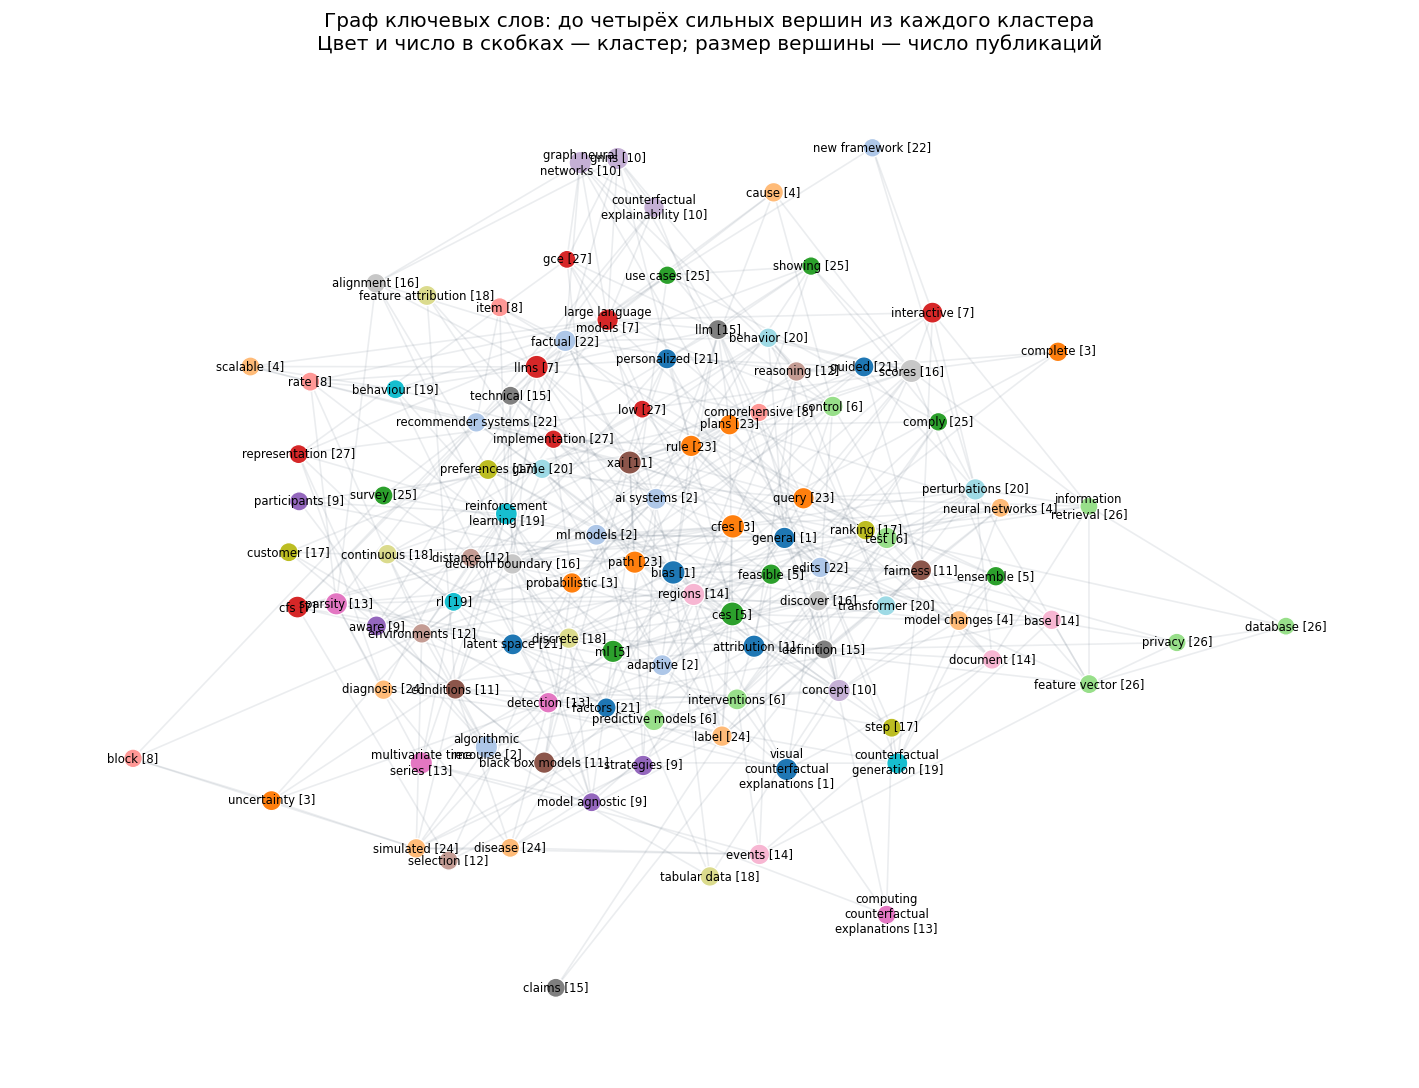

In [12]:
visible = []
for group in communities:
    visible.extend(sorted(group, key=lambda node: (-keyword_graph.degree(node, weight='weight'), node))[:4])
visible = sorted(set(visible))
view = keyword_graph.subgraph(visible).copy()
positions = nx.spring_layout(view, seed=RANDOM_STATE, weight='weight', k=1.4, iterations=150)
cmap = plt.get_cmap('tab20')

fig, ax = plt.subplots(figsize=(15, 11))
nx.draw_networkx_edges(view, positions, ax=ax, alpha=0.12, edge_color='#607080')
nx.draw_networkx_nodes(view, positions, ax=ax,
                       node_color=[cmap((partition[node] - 1) % 20) for node in view],
                       node_size=[90 + 7 * keyword_counts[node] for node in view],
                       linewidths=0.8, edgecolors='white')
nx.draw_networkx_labels(view, positions, ax=ax,
                        labels={node: fill(labels[node], 19) + f' [{partition[node]}]' for node in view},
                        font_size=7)
ax.set_title('Граф ключевых слов: до четырёх сильных вершин из каждого кластера\n'
             'Цвет и число в скобках — кластер; размер вершины — число публикаций')
ax.axis('off')
plt.show()

## 7. Центральности — пункт 7

Рассчитываются четыре разных показателя. Для кратчайших путей вес совместной
встречаемости преобразуется в длину $\ell_{ij}=1/w_{ij}$: частая связь становится
короткой. Использовать сам $w_{ij}$ как длину означало бы считать сильные связи
длинными. Все длины положительны.

| Показатель | Что измеряет | Учёт веса |
|:--|:--|:--|
| Degree | Число разных соседей, делённое на $n-1$ | Без весов |
| Betweenness | Долю кратчайших путей, проходящих через слово | Длина $1/w$ |
| Closeness | Обратную среднюю длину пути до других вершин | Длина $1/w$ |
| Eigenvector | Связи со словами, которые сами имеют высокий показатель | Сила связи $w$ |

Betweenness вычисляется точно для всех вершин. Eigenvector считается на крупнейшей
компоненте; за её пределами оставляются пропуски. Для closeness используется
поправка NetworkX на размер компоненты. При длинах меньше единицы взвешенная
closeness может превышать единицу; это не вероятность.

,Ключевое слово,Кластер,degree
ces,ces,5,0.05445
cfes,cfes,3,0.05262
bias,bias,1,0.05139
score,scores,16,0.04956
xai,xai,11,0.04864
llms,llms,7,0.04527
attribut,attribution,1,0.04313


,Ключевое слово,Кластер,betweenness
ces,ces,5,0.02324
visual counterfactu explan,visual counterfactual explanations,1,0.01901
bias,bias,1,0.01837
multivari time seri,multivariate time series,13,0.01670
ml,ml,5,0.01608
cfes,cfes,3,0.01583
xai,xai,11,0.01534


,Ключевое слово,Кластер,closeness
visual counterfactu explan,visual counterfactual explanations,1,0.49581
ces,ces,5,0.49490
bias,bias,1,0.48802
map,maps,1,0.48672
ml,ml,5,0.48562
general,general,1,0.48256
llms,llms,7,0.48235


,Ключевое слово,Кластер,eigenvector
graph neural network,graph neural networks,10,0.10272
gnns,gnns,10,0.10225
llms,llms,7,0.09424
bias,bias,1,0.09262
ces,ces,5,0.09225
visual counterfactu explan,visual counterfactual explanations,1,0.08917
cfes,cfes,3,0.08411


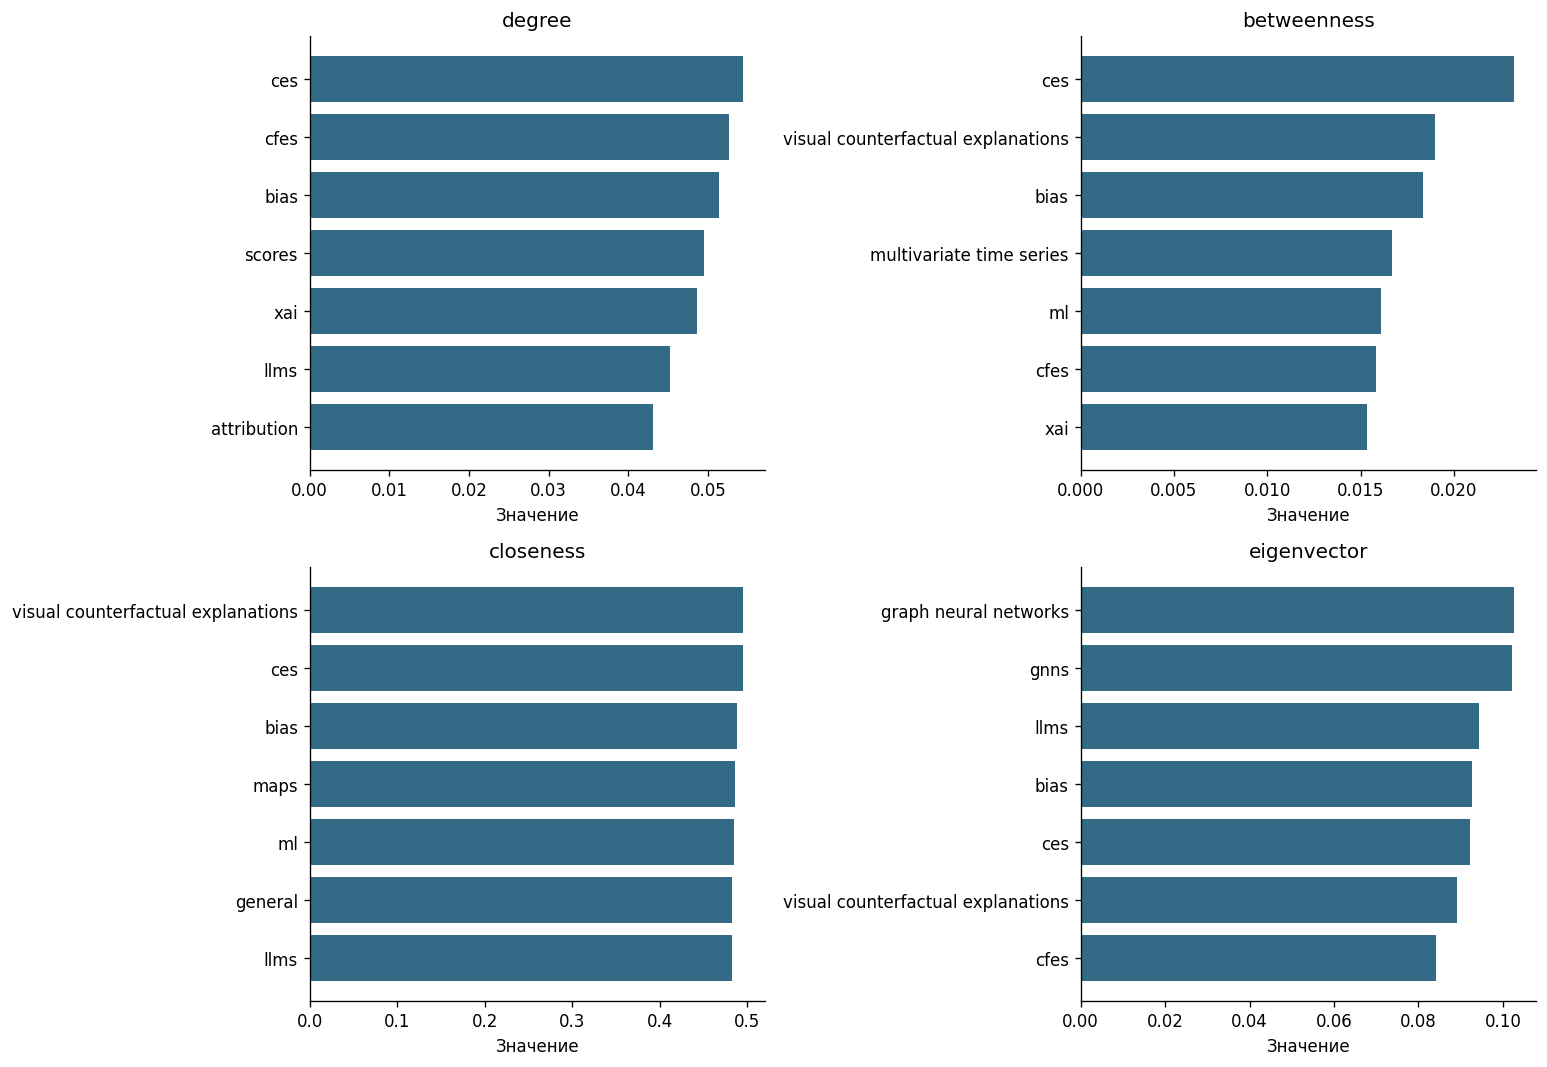

In [13]:
centrality = pd.DataFrame({
    'degree': nx.degree_centrality(keyword_graph),
    'betweenness': nx.betweenness_centrality(keyword_graph, weight='distance'),
    'closeness': nx.closeness_centrality(keyword_graph, distance='distance')
})
largest_component = max(nx.connected_components(keyword_graph), key=len)
eigenvector = nx.eigenvector_centrality(keyword_graph.subgraph(largest_component),
                                       weight='weight', max_iter=2000, tol=1e-9)
centrality['eigenvector'] = pd.Series(eigenvector)
centrality['Ключевое слово'] = pd.Series(labels)
centrality['Кластер'] = pd.Series(partition)
measures = ['degree', 'betweenness', 'closeness', 'eigenvector']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for measure, ax in zip(measures, axes.flat):
    top = centrality.nlargest(7, measure)
    display(top[['Ключевое слово', 'Кластер', measure]].round(5))
    top = top.iloc[::-1]
    ax.barh(top['Ключевое слово'], top[measure], color='#336b87')
    ax.set(title=measure, xlabel='Значение')
plt.tight_layout()
plt.show()

### Интерпретация центральностей

По degree лидируют `ces`, `cfes`, `bias`, `scores`, `xai`, `llms` и
`attribution`. Сокращения CE/CFE используются во многих постановках задачи,
поэтому имеют много разных соседей. Высокая степень `bias` показывает, что
вопрос смещения моделей пересекается с визуальными, причинными и прикладными
контрфактами.

По betweenness впереди `ces`, `visual counterfactual explanations`, `bias` и
`multivariate time series`. Они лежат на коротких путях между специализированными
группами. Например, визуальные контрфакты соединяют общую методологию объяснений
с компьютерным зрением, а временные ряды — общие критерии близости и разреженности
с задачами сигналов и прогнозирования.

По closeness лидируют `visual counterfactual explanations`, `ces`, `bias`,
`maps` и `ml`: от них мала средняя взвешенная длина пути до остальных терминов.
Это характеризует доступность из разных частей графа, но не качество конкретного
метода объяснения.

Eigenvector centrality выше всего у `graph neural networks`, `gnns`, `llms`,
`bias` и `ces`. В отличие от degree, этот показатель усиливается связями с другими
центральными словами. Поэтому плотное направление графовых объяснений оказывается
выше отдельных общих терминов. Одновременное присутствие `gnns` и полной формы
— ограничение морфологической нормализации: стемминг объединяет словоформы, но
не расшифровывает сокращения. Это следует учитывать при интерпретации рангов.

## 8. Граф публикаций и поиск — пункт 8

Вершина — arXiv ID без номера версии. Ребро существует тогда и только тогда,
когда у двух публикаций есть хотя бы один общий выбранный тег:

$$w_{ab}=|K_a\cap K_b|.$$

Граф строится через обратный индекс `тег → публикации`. Для каждого тега
соединяются пары содержащих его работ. В ребре сохраняются вес и общие теги,
поэтому рекомендацию можно объяснить. Все публикации добавляются в граф,
даже если у них нет соседей.

Поиск возвращает соседей исходной вершины по убыванию веса. При равенстве веса
используется arXiv ID для воспроизводимого порядка. Отсутствие общей вершины-тега
означает отсутствие прямой рекомендации. Путь через несколько статей сам по себе
не гарантирует общих тегов у его концов, поэтому в основной рейтинг он не включён.

Публикаций: 761
Связей: 12165
Компонент связности: 1
Изолированных публикаций: 0


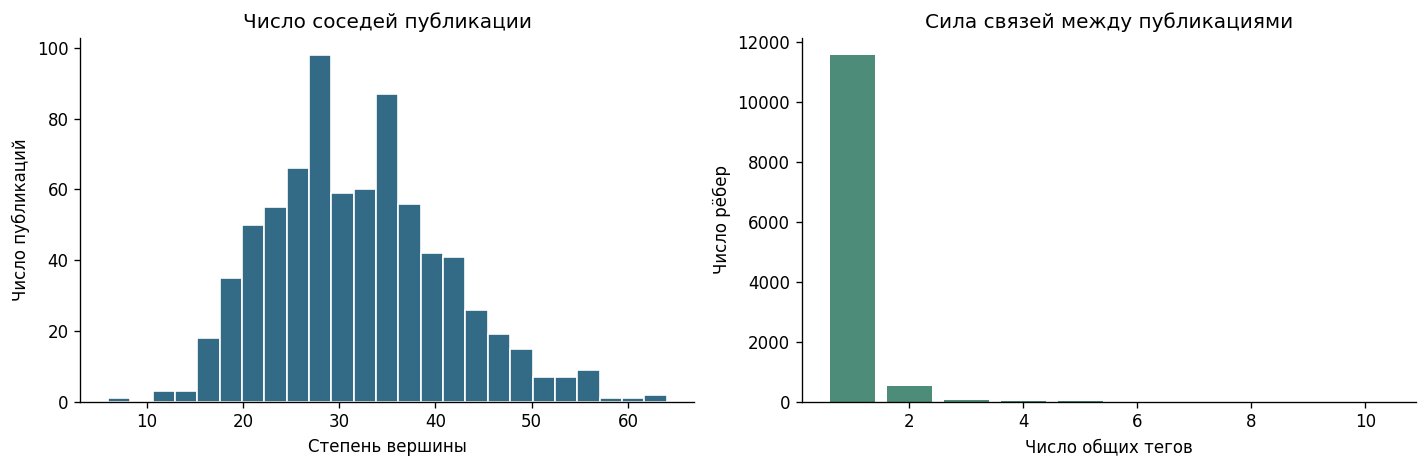

In [14]:
def build_publication_graph(frame):
    graph = nx.Graph()
    inverted = defaultdict(list)
    for row in frame.itertuples():
        graph.add_node(row.id, title=row.title, url=row.url)
        for term in sorted(set(row.keywords)):
            inverted[term].append(row.id)
    for term, paper_ids in inverted.items():
        for left, right in combinations(paper_ids, 2):
            if not graph.has_edge(left, right):
                graph.add_edge(left, right, weight=0, common_keywords=[])
            graph[left][right]['weight'] += 1
            graph[left][right]['common_keywords'].append(term)
    for left, right, edge in graph.edges(data=True):
        edge['common_keywords'].sort()
    return graph

publication_graph = build_publication_graph(corpus)
papers = corpus.set_index('id')
paper_tags = papers['keywords'].map(set).to_dict()
print('Публикаций:', publication_graph.number_of_nodes())
print('Связей:', publication_graph.number_of_edges())
print('Компонент связности:', nx.number_connected_components(publication_graph))
print('Изолированных публикаций:', nx.number_of_isolates(publication_graph))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([degree for node, degree in publication_graph.degree()], bins=25,
             color='#336b87', edgecolor='white')
axes[0].set(title='Число соседей публикации', xlabel='Степень вершины', ylabel='Число публикаций')
weight_counts = Counter(edge['weight'] for a, b, edge in publication_graph.edges(data=True))
axes[1].bar(sorted(weight_counts), [weight_counts[k] for k in sorted(weight_counts)], color='#4c8c78')
axes[1].set(title='Сила связей между публикациями', xlabel='Число общих тегов', ylabel='Число рёбер')
plt.tight_layout()
plt.show()

In [15]:
def find_publications(query):
    query = str(query).strip()
    mask = corpus['id'].eq(query) | corpus['title'].str.contains(query, case=False, regex=False)
    return corpus.loc[mask, ['id', 'title', 'published', 'url']].reset_index(drop=True)

def resolve_publication(query):
    query = str(query).strip()
    if not query:
        raise ValueError('Введите arXiv ID или часть названия.')
    if query in publication_graph:
        return query
    matches = find_publications(query)
    if len(matches) == 0:
        raise ValueError('Публикация не найдена в корпусе.')
    if len(matches) > 1:
        display(matches)
        raise ValueError('Найдено несколько статей. Укажите ID из таблицы.')
    return matches.iloc[0]['id']

def similar_publications(paper_id, top_n=5, graph=None):
    graph = publication_graph if graph is None else graph
    if paper_id not in graph:
        raise KeyError(f'В графе нет публикации {paper_id}.')
    if isinstance(top_n, bool) or not isinstance(top_n, (int, np.integer)) or top_n <= 0:
        raise ValueError('top_n должен быть положительным целым числом.')
    neighbours = sorted(graph[paper_id], key=lambda other: (-graph[paper_id][other]['weight'], other))
    rows = []
    for other in neighbours[:top_n]:
        edge = graph[paper_id][other]
        rows.append({'id': other, 'title': graph.nodes[other]['title'],
                     'weight': edge['weight'], 'common_keywords': edge['common_keywords'].copy(),
                     'url': graph.nodes[other]['url']})
    return pd.DataFrame(rows, columns=['id', 'title', 'weight', 'common_keywords', 'url'])

def show_recommendations(paper_id, top_n=5):
    print('Исходная статья:', papers.at[paper_id, 'title'])
    print('Ссылка:', papers.at[paper_id, 'url'])
    print('Теги:', ', '.join(labels[tag] for tag in papers.at[paper_id, 'keywords']))
    result = similar_publications(paper_id, top_n)
    table = result.copy()
    table['common_keywords'] = table['common_keywords'].map(lambda tags: ', '.join(labels[t] for t in tags))
    with pd.option_context('display.max_colwidth', None):
        display(table.rename(columns={'weight': 'Общих тегов', 'common_keywords': 'Общие теги'}))
    return result

### Поиск для выбранной пользователем статьи

В следующей ячейке можно изменить `PUBLICATION`: указать arXiv ID из корпуса
или однозначную часть названия. `TOP_N` задаёт число рекомендаций. Для просмотра
доступных работ можно выполнить `find_publications('graph')`.
По умолчанию выбран пример про выполнимые контрфактические объяснения.

Исходная статья: FCx: An algorithm for finding Feasible Counterfactual Explanations
Ссылка: https://arxiv.org/abs/2609.19383
Теги: feasibility constraints, feasible counterfactual explanations, low cost, absolute, dense, lof, explanations identify, job, reside, density estimator, multiple metrics, race


,id,title,Общих тегов,Общие теги,url
0,2002.04862,Convex Density Constraints for Computing Plausible Counterfactual Explanations,1,density estimator,https://arxiv.org/abs/2002.04862
1,2101.01292,GeCo: Quality Counterfactual Explanations in Real Time,1,feasible counterfactual explanations,https://arxiv.org/abs/2101.01292
2,2111.01235,Low-Cost Algorithmic Recourse for Users With Uncertain Cost Functions,1,low cost,https://arxiv.org/abs/2111.01235
3,2211.02151,Decomposing Counterfactual Explanations for Consequential Decision Making,1,low cost,https://arxiv.org/abs/2211.02151
4,2211.15370,Clarity: an improved gradient method for producing quality visual counterfactual explanations,1,explanations identify,https://arxiv.org/abs/2211.15370


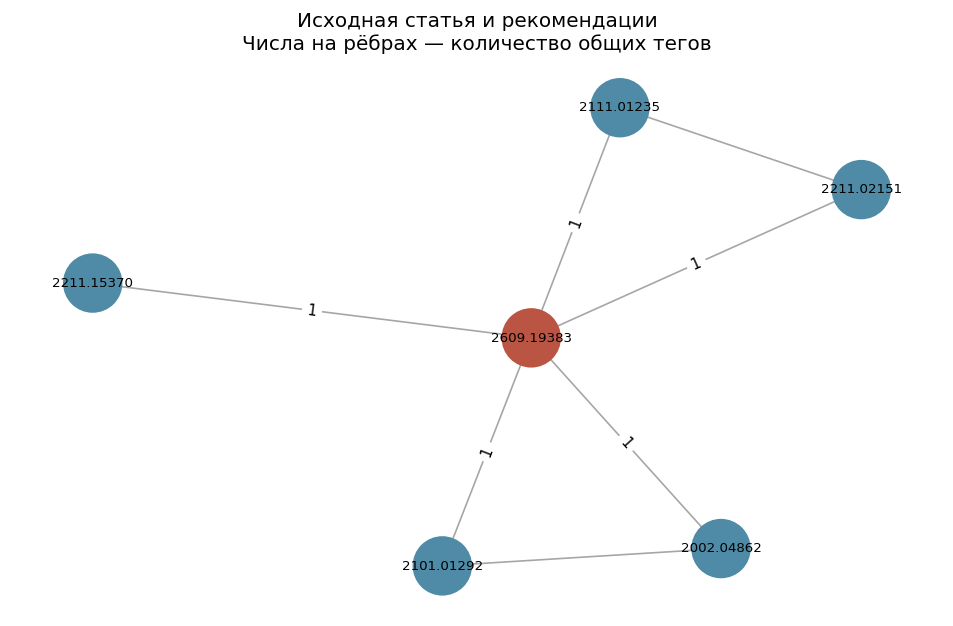

In [16]:
PUBLICATION = '2609.19383'
TOP_N = 5

selected_id = resolve_publication(PUBLICATION)
recommendations = show_recommendations(selected_id, TOP_N)

neighbour_ids = recommendations['id'].tolist()
local_graph = publication_graph.subgraph([selected_id, *neighbour_ids]).copy()
positions = nx.spring_layout(local_graph, seed=RANDOM_STATE, weight='weight')
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(local_graph, positions, ax=ax, alpha=0.35,
                       width=[0.5 + edge['weight'] / 2 for a, b, edge in local_graph.edges(data=True)])
nx.draw_networkx_nodes(local_graph, positions, ax=ax,
                       node_color=['#ba5544' if node == selected_id else '#4f8ba6' for node in local_graph],
                       node_size=1200)
nx.draw_networkx_labels(local_graph, positions, ax=ax, font_size=8,
                        labels={node: node for node in local_graph})
nx.draw_networkx_edge_labels(local_graph, positions, ax=ax,
                             edge_labels={(selected_id, other): publication_graph[selected_id][other]['weight']
                                          for other in neighbour_ids}, font_size=9)
ax.set_title('Исходная статья и рекомендации\nЧисла на рёбрах — количество общих тегов')
ax.axis('off')
plt.show()

## 9. Проверка поиска — пункт 9

Сначала используется небольшой граф с известными ответами: проверяются веса,
порядок выдачи, равенство весов и изолированная вершина. Затем для каждой пары
статей реального корпуса независимо вычисляется пересечение тегов: проверяется
не только корректность существующих рёбер, но и отсутствие пропущенных связей.
Для каждой исходной публикации результат поиска сравнивается с полным перебором
остальных статей. Отдельно проверяются неверный ID и недопустимое число результатов.

In [17]:
toy = pd.DataFrame([
    {'id': 'A', 'title': 'Source', 'url': 'A', 'keywords': ['x', 'y', 'x']},
    {'id': 'B', 'title': 'Both tags', 'url': 'B', 'keywords': ['x', 'y']},
    {'id': 'C', 'title': 'One tag', 'url': 'C', 'keywords': ['x']},
    {'id': 'D', 'title': 'Isolated', 'url': 'D', 'keywords': ['z']},
    {'id': 'E', 'title': 'Tie', 'url': 'E', 'keywords': ['y']}
])
toy_graph = build_publication_graph(toy)
toy_result = similar_publications('A', 10, graph=toy_graph)
assert toy_result['id'].tolist() == ['B', 'C', 'E']
assert toy_result['weight'].tolist() == [2, 1, 1]
assert toy_graph['A']['B']['common_keywords'] == ['x', 'y']
assert similar_publications('A', 1, graph=toy_graph)['id'].tolist() == ['B']
assert similar_publications('D', graph=toy_graph).empty

for left, right in combinations(paper_tags, 2):
    common = paper_tags[left] & paper_tags[right]
    assert publication_graph.has_edge(left, right) == bool(common)
    if common:
        edge = publication_graph[left][right]
        assert edge['weight'] == len(common)
        assert set(edge['common_keywords']) == common

for source, source_tags in paper_tags.items():
    expected = [(other, len(source_tags & tags)) for other, tags in paper_tags.items()
                if other != source and source_tags & tags]
    expected = sorted(expected, key=lambda pair: (-pair[1], pair[0]))[:5]
    actual = similar_publications(source, 5)
    assert list(zip(actual['id'], actual['weight'])) == expected
    assert source not in set(actual['id']) and actual['id'].is_unique

for bad_top_n in (0, -1, 1.5, True):
    try:
        similar_publications(selected_id, bad_top_n)
    except ValueError:
        pass
    else:
        raise AssertionError('Не проверяется top_n.')
try:
    similar_publications('unknown-id')
except KeyError:
    pass
else:
    raise AssertionError('Не проверяется существование публикации.')

assert resolve_publication(papers.at[selected_id, 'title']) == selected_id
assert nx.number_of_selfloops(publication_graph) == 0
print(f'Тесты пройдены: проверены все {len(paper_tags)} запросов и '
      f'{len(paper_tags) * (len(paper_tags) - 1) // 2:,} пар публикаций.')

Тесты пройдены: проверены все 761 запросов и 289,180 пар публикаций.


### Содержательная проверка рекомендаций

Тесты выше подтверждают корректность графа и сортировки. Они не измеряют смысловую
близость статей. Для неё отдельно рассматриваются три запроса из разных направлений:
выполнимость изменений, объяснения графовых моделей и справедливость рекомендаций.

In [18]:
case_ids = [
    '2609.19383',
    corpus.loc[corpus['title'].str.contains('graph neural', case=False, regex=False), 'id'].iloc[0],
    corpus.loc[corpus['title'].str.contains('fair', case=False, regex=False), 'id'].iloc[0]
]
case_results = {}
for paper_id in case_ids:
    case_results[paper_id] = show_recommendations(paper_id, 5)

Исходная статья: FCx: An algorithm for finding Feasible Counterfactual Explanations
Ссылка: https://arxiv.org/abs/2609.19383
Теги: feasibility constraints, feasible counterfactual explanations, low cost, absolute, dense, lof, explanations identify, job, reside, density estimator, multiple metrics, race


,id,title,Общих тегов,Общие теги,url
0,2002.04862,Convex Density Constraints for Computing Plausible Counterfactual Explanations,1,density estimator,https://arxiv.org/abs/2002.04862
1,2101.01292,GeCo: Quality Counterfactual Explanations in Real Time,1,feasible counterfactual explanations,https://arxiv.org/abs/2101.01292
2,2111.01235,Low-Cost Algorithmic Recourse for Users With Uncertain Cost Functions,1,low cost,https://arxiv.org/abs/2111.01235
3,2211.02151,Decomposing Counterfactual Explanations for Consequential Decision Making,1,low cost,https://arxiv.org/abs/2211.02151
4,2211.15370,Clarity: an improved gradient method for producing quality visual counterfactual explanations,1,explanations identify,https://arxiv.org/abs/2211.15370


Исходная статья: A Comparative Study of Counterfactual Explainers for Graph Neural Networks Enabling Multiple Types of Graph Edit
Ссылка: https://arxiv.org/abs/2609.05113
Теги: counterfactual explainability, modifications required, node classification, predefined output, graph edit, sota, graph structured data, diverse set, fall short, future research, multi class, input graph


,id,title,Общих тегов,Общие теги,url
0,2210.11695,Global Counterfactual Explainer for Graph Neural Networks,2,"counterfactual explainability, input graph",https://arxiv.org/abs/2210.11695
1,2403.06514,Structure Your Data: Towards Semantic Graph Counterfactuals,2,"graph edit, sota",https://arxiv.org/abs/2403.06514
2,2004.11165,Multi-Objective Counterfactual Explanations,1,diverse set,https://arxiv.org/abs/2004.11165
3,2010.10596,Counterfactual Explanations and Algorithmic Recourses for Machine Learning: A Review,1,counterfactual explainability,https://arxiv.org/abs/2010.10596
4,2107.04086,Robust Counterfactual Explanations on Graph Neural Networks,1,input graph,https://arxiv.org/abs/2107.04086


Исходная статья: Do Fair Models Reason Fairly? Counterfactual Explanation Consistency for Procedural Fairness in Credit Decisions
Ссылка: https://arxiv.org/abs/2605.12701
Теги: explanation consistency, fairness metrics, procedure, hidden, bias, data demonstrate, individual level, model reasoning, mortgage, nearest neighbor counterfactual, substantially reduces, outcome


,id,title,Общих тегов,Общие теги,url
0,2603.11140,Procedural Fairness via Group Counterfactual Explanation,3,"model reasoning, procedure, substantially reduces",https://arxiv.org/abs/2603.11140
1,2006.16793,Counterfactual explanation of machine learning survival models,1,data demonstrate,https://arxiv.org/abs/2006.16793
2,2010.06529,On the Fairness of Causal Algorithmic Recourse,1,individual level,https://arxiv.org/abs/2010.06529
3,2106.02597,Model-agnostic and Scalable Counterfactual Explanations via Reinforcement Learning,1,procedure,https://arxiv.org/abs/2106.02597
4,2106.12563,Feature Attributions and Counterfactual Explanations Can Be Manipulated,1,bias,https://arxiv.org/abs/2106.12563


### Интерпретация поиска

Для статьи *FCx: An algorithm for finding Feasible Counterfactual Explanations*
поиск находит работы о плотностных ограничениях, выполнимых объяснениях и дешёвых
алгоритмических рекомендациях. У каждой из первых пяти статей один общий тег,
поэтому результат тематически правдоподобен, но уверенность графа невысока.

Для статьи о сравнении объяснителей графовых нейронных сетей первые результаты
*Global Counterfactual Explainer for Graph Neural Networks* и
*Structure Your Data: Towards Semantic Graph Counterfactuals* имеют по два общих
тега. Совпадают не только общие слова об объяснениях, но и `input graph` либо
`graph edit`, поэтому эта выдача уже отражает конкретную постановку задачи.

Для статьи о согласованности и справедливости объяснений наиболее близка
*Procedural Fairness via Group Counterfactual Explanation*: общий вес равен трём,
а теги относятся к процедуре, рассуждению модели и существенному снижению
расхождений. Остальные результаты имеют вес один и должны рассматриваться как
более слабые рекомендации.

Таким образом, вес ребра даёт прозрачное объяснение результата, но не заменяет
семантическую экспертизу. Общий редкий тег обычно информативнее общего широкого
слова, хотя в текущей модели оба дают единицу веса. Возможное развитие — учитывать
IDF тега или совместить графовый балл с косинусной близостью аннотаций.

## Итоговые выводы

Через официальный arXiv API получено 766 записей. После удаления пяти записей,
не прошедших буквальную тематическую проверку, корпус содержит 761 уникальную
публикацию с 21.01.2020 по 17.09.2026. Обязательные поля заполнены, повторов ID
и названий нет. В корпусе 146 067 словоупотреблений и 7 724 различные словоформы.

В средней части рангового распределения слов наклон равен −0,936 при R²=0,995;
на всём словаре — −1,371 при R²=0,964. Это согласуется с характерной формой закона
Ципфа, но не является доказательством степенного распределения.

Из названий и аннотаций извлечено по 12 TF-IDF-тегов: униграмм, биграмм и
триграмм. Нормализация выполнена английским Snowball-стеммингом; границы
предложений и удалённые стоп-слова не создают ложные n-граммы. Получено 3 270
различных тегов.

Полный граф ключевых слов содержит 3 270 вершин и 49 313 рёбер и является
связным. Louvain выделил 27 сообществ, модульность равна 0,336. Тематически
выделяются визуальные объяснения, algorithmic recourse, клинические временные
данные, LLM, графовые модели, справедливость, многомерные ряды и приватный поиск.
Похожие значения модульности при разных seed и низкий ARI показывают, что точные
границы сообществ нестабильны; это честное ограничение разведочного анализа.

Центральности описывают разные роли: CE/CFE и `bias` имеют много соседей;
визуальные объяснения и временные ряды соединяют направления; графовые нейронные
сети связаны с другими влиятельными терминами. Поэтому одного показателя
недостаточно для определения «главного» понятия области.

Граф публикаций содержит 761 вершину и 12 165 рёбер и является связным. Поиск
возвращает статьи по числу общих тегов и объясняет каждую рекомендацию этими
тегами. Корректность весов и сортировки проверена на искусственном примере,
для всех 761 запросов и всех 289 180 пар настоящих публикаций.

Ограничения: поиск arXiv зависит от формулировок в названии и аннотации; стемминг
не объединяет сокращения с полными формами; TF-IDF не различает важность
синонимичных тегов; Louvain даёт нестабильные границы; общий тег не гарантирует
одинаковый исследовательский вопрос. Поэтому граф удобен для объяснимого поиска
и обзора корпуса, но итоговую тематическую близость должен оценивать человек.